In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [2]:
# Load dataset
ds_train = tfds.load("stl10", split="train", as_supervised=False)
ds_test  = tfds.load("stl10", split="test",  as_supervised=False)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.3N4J51_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.3N4J51_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


In [3]:
def preprocess(sample):
    img = tf.cast(sample["image"], tf.float32) / 255.0  # [0 to 1] tho fir sigmod use hoga
    gray = tf.image.rgb_to_grayscale(img)
    return gray, img

In [4]:
BATCH_SIZE = 32

train_ds = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


## Checking Data

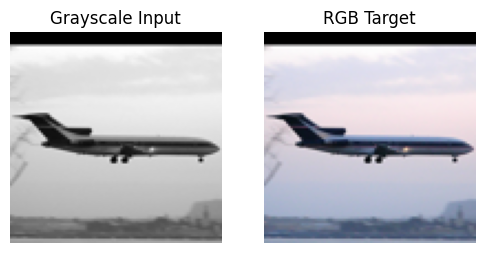

In [5]:
for gray, rgb in test_ds.take(1):
    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title("Grayscale Input")
    plt.imshow(gray[-15].numpy(), cmap="gray") # .squeeze()
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("RGB Target")
    plt.imshow(rgb[-15].numpy())
    plt.axis("off")

    plt.show()

# Model building

In [8]:
from tensorflow.keras import layers, models

inp = layers.Input(shape=(96, 96, 1))

# -------- Encoder --------
e1 = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(inp)   # 48x48
e2 = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(e1)   # 24x24
e3 = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(e2)   # 12x12

# 🔥 Bottleneck (6x6, 512 feature maps)
latent = layers.Conv2D(512, 3, strides=2, padding="same", activation="relu")(e3)  # 6x6x512

# -------- Decoder --------
d1 = layers.UpSampling2D(size=2, interpolation="nearest")(latent)  # 12x12
d1 = layers.Conv2D(256, 3, padding="same", activation="relu")(d1)
d1 = layers.Concatenate()([d1, e3])

d2 = layers.UpSampling2D(size=2, interpolation="nearest")(d1)      # 24x24
d2 = layers.Conv2D(128, 3, padding="same", activation="relu")(d2)
d2 = layers.Concatenate()([d2, e2])

d3 = layers.UpSampling2D(size=2, interpolation="nearest")(d2)      # 48x48
d3 = layers.Conv2D(64, 3, padding="same", activation="relu")(d3)
d3 = layers.Concatenate()([d3, e1])

d4 = layers.UpSampling2D(size=2, interpolation="nearest")(d3)      # 96x96
out = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(d4)

# -------- Model --------
autoencoder = models.Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mae")


In [9]:
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 48, 48,    │        640 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 24, 24,    │     73,856 │ conv2d_16[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 12, 12,    │    295,168 │ conv2d_17[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 6, 6, 512) │  1,180,160 │ conv2d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 12, 12,    │          0 │ conv2d_19[0][0]   │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 12, 12,    │  1,179,904 │ up_sampling2d_8[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 12, 12,    │          0 │ conv2d_20[0][0],  │
│ (Concatenate)       │ 512)              │            │ conv2d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 24, 24,    │          0 │ concatenate_6[0]… │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 24, 24,    │    589,952 │ up_sampling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 24, 24,    │          0 │ conv2d_21[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_10    │ (None, 48, 48,    │          0 │ concatenate_7[0]… │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 48, 48,    │    147,520 │ up_sampling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 48, 48,    │          0 │ conv2d_22[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_11    │ (None, 96, 96,    │          0 │ concatenate_8[0]… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 96, 96, 3) │      3,459 │ up_sampling2d_11… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,470,659 (13.24 MB)

 Trainable params: 3,470,659 (13.24 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 50

history = autoencoder.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 138ms/step - loss: 0.1288 - val_loss: 0.0670
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - loss: 0.0646 - val_loss: 0.0602
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - loss: 0.0602 - val_loss: 0.0594
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - loss: 0.0575 - val_loss: 0.0582
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - loss: 0.0554 - val_loss: 0.0536
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - loss: 0.0534 - val_loss: 0.0533
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 0.0534 - val_loss: 0.0516
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 0.0516 - val_loss: 0.0517
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - loss: 0.0511 - val_loss: 0.0505
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - loss: 0.0503 - val_loss: 0.0530
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - loss: 0.0505 - val_loss: 0.0508
Epoch 12/50
157/157 ━━━━━━━━

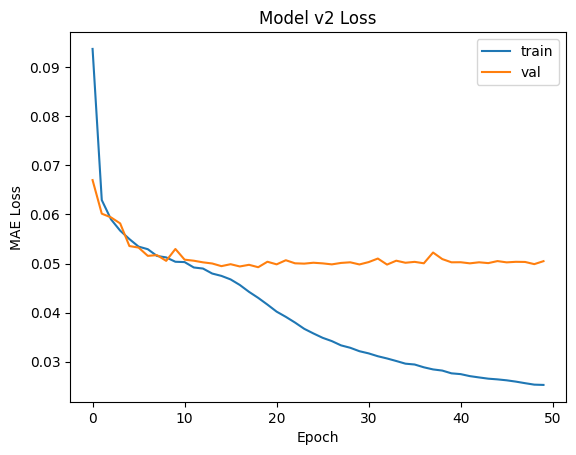

In [16]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.xlabel("Epoch")
plt.title("Model v2 Loss")
plt.ylabel("MAE Loss")
plt.show()

# Checking performance

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


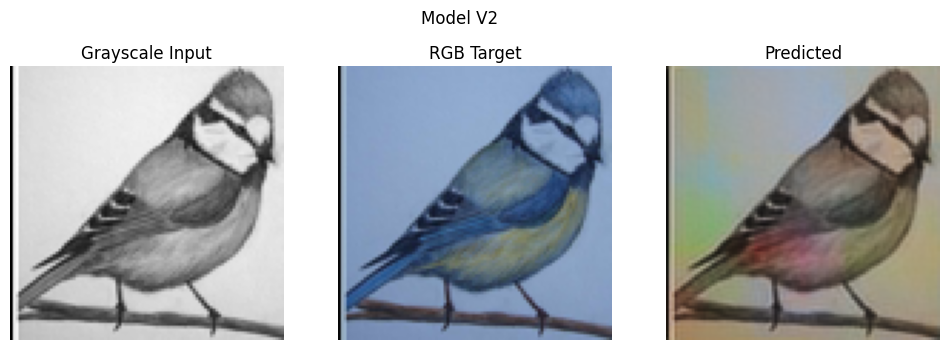

In [57]:
b1 = iter(test_ds)
next(b1)
next(b1)
batch = next(b1)
bw, rgb = batch
index = 8
img_bw, img_rgb = bw[index],rgb[index]
img_bw.shape, img_rgb.shape

y_pred = autoencoder.predict(img_bw[None, ...])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Grayscale Input")
plt.imshow(img_bw.numpy().squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("RGB Target")
plt.imshow(img_rgb.numpy())
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(y_pred)
plt.axis("off")
plt.suptitle("Model V2")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


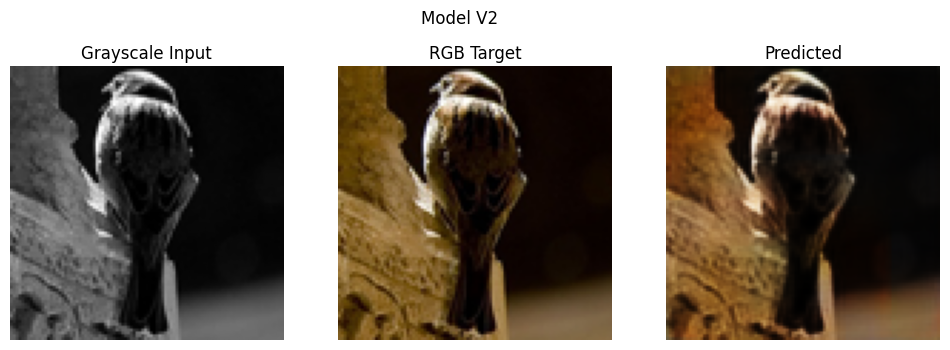

In [37]:
b1 = iter(train_ds)
batch = next(b1)
bw, rgb = batch
index = 17
img_bw, img_rgb = bw[index],rgb[index]
img_bw.shape, img_rgb.shape

y_pred = autoencoder.predict(img_bw[None, ...])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Grayscale Input")
plt.imshow(img_bw.numpy().squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("RGB Target")
plt.imshow(img_rgb.numpy())
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted")
plt.imshow(y_pred)
plt.axis("off")
plt.suptitle("Model V2")

plt.show()



```
from tensorflow.keras.models import load_model
model = load_model("bw2rgb_Model_v2.keras")

y = model.predict(img_bw[None, ...])
```



In [31]:
autoencoder.save("bw2rgb_Model_v2.keras")